<a href="https://colab.research.google.com/github/CarlosOrte/Descriptive-and-Predictive-Analytics-Code/blob/main/Practica20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Práctica 20: Ejercicios de EDA usando AirQuality**

---

**Objetivo:** Realizar un Análisis Exploratorio de Datos (EDA) aplicando técnicas estadísticas y de visualización para comprender la estructura, distribución y relaciones dentro de un conjunto de datos.

**Maestría:** Maestría en Inteligencia Artificial y Analítica de Datos  

**Materia:** Programación para Analítica Descriptiva y Predictiva  

**Alumno:** 266231



---



Nota: Este tema está compuesto por diversos módulos que se han separado para un mejor estudio del tema.

##1. Introducción del dataset

In [72]:
# importamos pandas y cargamos el archivo AirQuality.csv
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/AirQuality.csv', sep=";")
df.shape



(9471, 17)

Descripción de variables:

* Date: Fecha de la medición
* Time: Hora
* CO(GT): Concentración de monóxido de carbono
* PT08.S1(CO): Sensor de CO
* NMHC(GT): Hidrocarburos no metánicos
* NOx(GT): Óxidos de nitrógeno
* Temperature: Temperatura ambiente
* RH: Humedad relativa

In [73]:
df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,"2,6",1360.0,150.0,"11,9",1046.0,166.0,1056.0,113.0,1692.0,1268.0,"13,6","48,9","0,7578",NaN,NaN
1,10/03/2004,19.00.00,2,1292.0,112.0,"9,4",955.0,103.0,1174.0,92.0,1559.0,972.0,"13,3","47,7","0,7255",NaN,NaN
2,10/03/2004,20.00.00,"2,2",1402.0,88.0,"9,0",939.0,131.0,1140.0,114.0,1555.0,1074.0,"11,9","54,0","0,7502",NaN,NaN
3,10/03/2004,21.00.00,"2,2",1376.0,80.0,"9,2",948.0,172.0,1092.0,122.0,1584.0,1203.0,"11,0","60,0","0,7867",NaN,NaN
4,10/03/2004,22.00.00,"1,6",1272.0,51.0,"6,5",836.0,131.0,1205.0,116.0,1490.0,1110.0,"11,2","59,6","0,7888",NaN,NaN


In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9471 entries, 0 to 9470
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   object 
 2   CO(GT)         9357 non-null   object 
 3   PT08.S1(CO)    9357 non-null   float64
 4   NMHC(GT)       9357 non-null   float64
 5   C6H6(GT)       9357 non-null   object 
 6   PT08.S2(NMHC)  9357 non-null   float64
 7   NOx(GT)        9357 non-null   float64
 8   PT08.S3(NOx)   9357 non-null   float64
 9   NO2(GT)        9357 non-null   float64
 10  PT08.S4(NO2)   9357 non-null   float64
 11  PT08.S5(O3)    9357 non-null   float64
 12  T              9357 non-null   object 
 13  RH             9357 non-null   object 
 14  AH             9357 non-null   object 
 15  Unnamed: 15    0 non-null      float64
 16  Unnamed: 16    0 non-null      float64
dtypes: float64(10), object(7)
memory usage: 1.2+ MB


##📊 2. Exploración inicial de datos

* Valores faltantes



In [75]:
df.isnull().sum()

,0
Date,114
Time,114
CO(GT),114
PT08.S1(CO),114
NMHC(GT),114
C6H6(GT),114
PT08.S2(NMHC),114
NOx(GT),114
PT08.S3(NOx),114
NO2(GT),114


* Tipos de variables

In [76]:
df.dtypes

,0
Date,object
Time,object
CO(GT),object
PT08.S1(CO),float64
NMHC(GT),float64
C6H6(GT),object
PT08.S2(NMHC),float64
NOx(GT),float64
PT08.S3(NOx),float64
NO2(GT),float64


___________________________________________________________________________

* Outliers





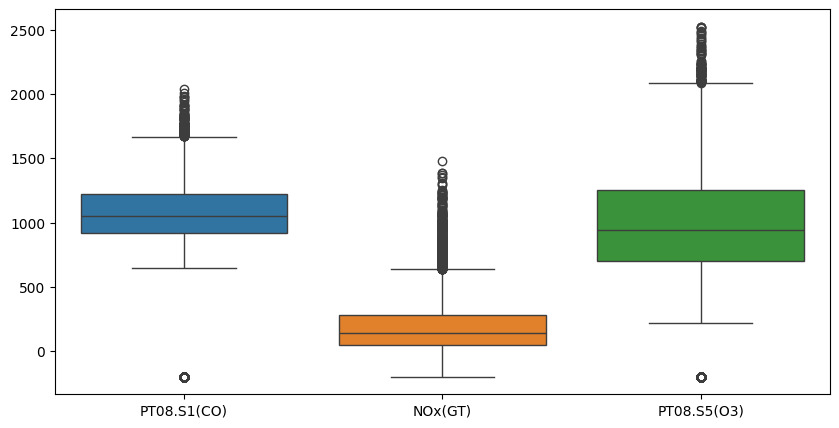

In [77]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.boxplot(data=df[['PT08.S1(CO)', 'NOx(GT)', 'PT08.S5(O3)']])
plt.show()

Se observaron valores atípicos en varias variables mediante el uso de boxplots. Además, se identificaron valores de -200, los cuales representan datos faltantes o errores en la medición, por lo que deben tratarse adecuadamente antes del análisis.

*   Estadísticas descriptivas



In [78]:
df.describe()

,PT08.S1(CO),NMHC(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),Unnamed: 15,Unnamed: 16
count,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,0.0,0.0
mean,1048.990061,-159.090093,894.595276,168.616971,794.990168,58.148873,1391.479641,975.072032,NaN,NaN
std,329.832710,139.789093,342.333252,257.433866,321.993552,126.940455,467.210125,456.938184,NaN,NaN
min,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,NaN,NaN
25%,921.000000,-200.000000,711.000000,50.000000,637.000000,53.000000,1185.000000,700.000000,NaN,NaN
50%,1053.000000,-200.000000,895.000000,141.000000,794.000000,96.000000,1446.000000,942.000000,NaN,NaN
75%,1221.000000,-200.000000,1105.000000,284.000000,960.000000,133.000000,1662.000000,1255.000000,NaN,NaN
max,2040.000000,1189.000000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,NaN,NaN


##3. Análisis univariado

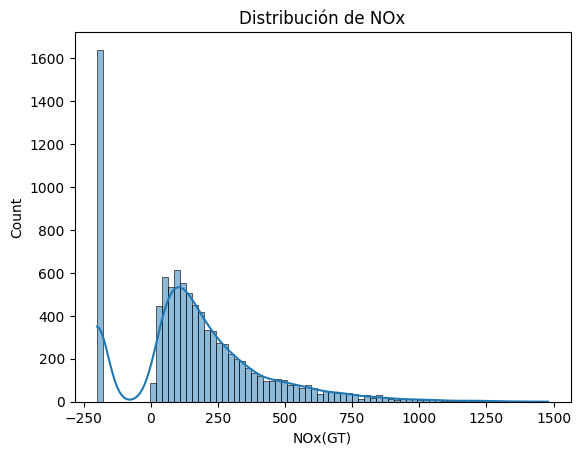

In [79]:
sns.histplot(df['NOx(GT)'], kde=True)
plt.title('Distribución de NOx')
plt.show()

La variable NOx(GT) presenta una distribución sesgada hacia la derecha, lo que indica que la mayoría de las mediciones se concentran en valores bajos, pero existen valores extremos altos. El boxplot confirma la presencia de múltiples outliers, lo cual es común en datos ambientales debido a picos de contaminación.

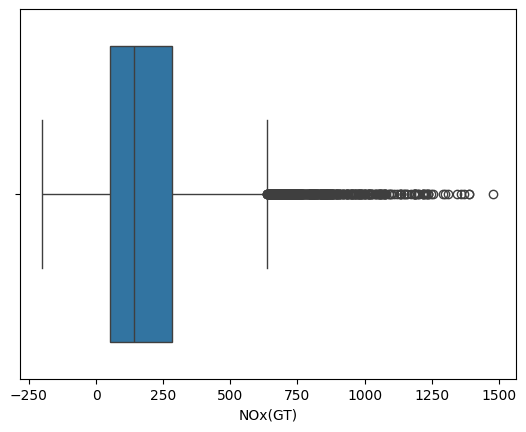

In [80]:
sns.boxplot(x=df['NOx(GT)'])
plt.show()

Se observan valores atípicos fuera del rango intercuartílico, indicando variabilidad en la concentración de NOx.

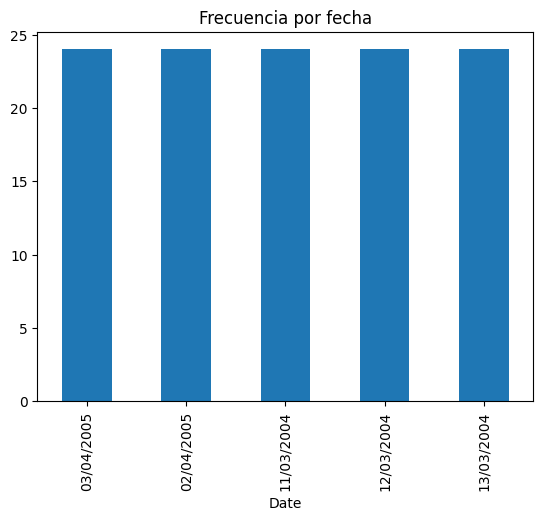

In [81]:
df['Date'].value_counts().head().plot(kind='bar')
plt.title('Frecuencia por fecha')
plt.show()

Algunas fechas presentan mayor número de registros, lo que indica concentración de mediciones en ciertos días.

##4. Análisis bivariado

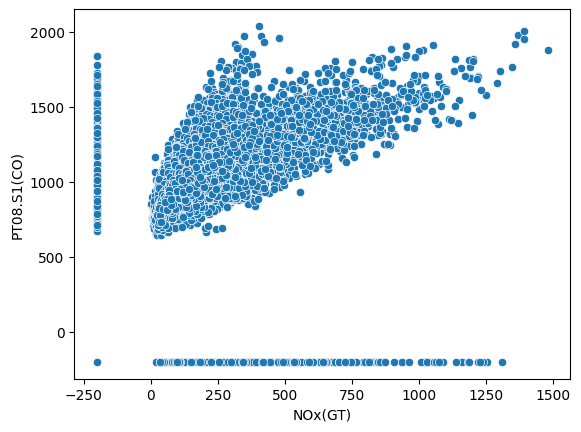

In [82]:
sns.scatterplot(x=df['NOx(GT)'], y=df['PT08.S1(CO)'])
plt.show()

Se observa una posible relación entre NOx y CO, donde a mayores concentraciones de un contaminante, también aumenta el otro.

##5. Análisis multivariado

In [83]:
df['CO(GT)'] = df['CO(GT)'].str.replace(',', '.').astype(float)
df['C6H6(GT)'] = df['C6H6(GT)'].str.replace(',', '.').astype(float)
df['T'] = df['T'].str.replace(',', '.').astype(float)
df['RH'] = df['RH'].str.replace(',', '.').astype(float)
df['AH'] = df['AH'].str.replace(',', '.').astype(float)

In [84]:
df = df.drop(columns=['Unnamed: 15', 'Unnamed: 16'])

In [85]:
df = df.replace(-200, pd.NA)

In [86]:
df = df.apply(pd.to_numeric, errors='coerce')

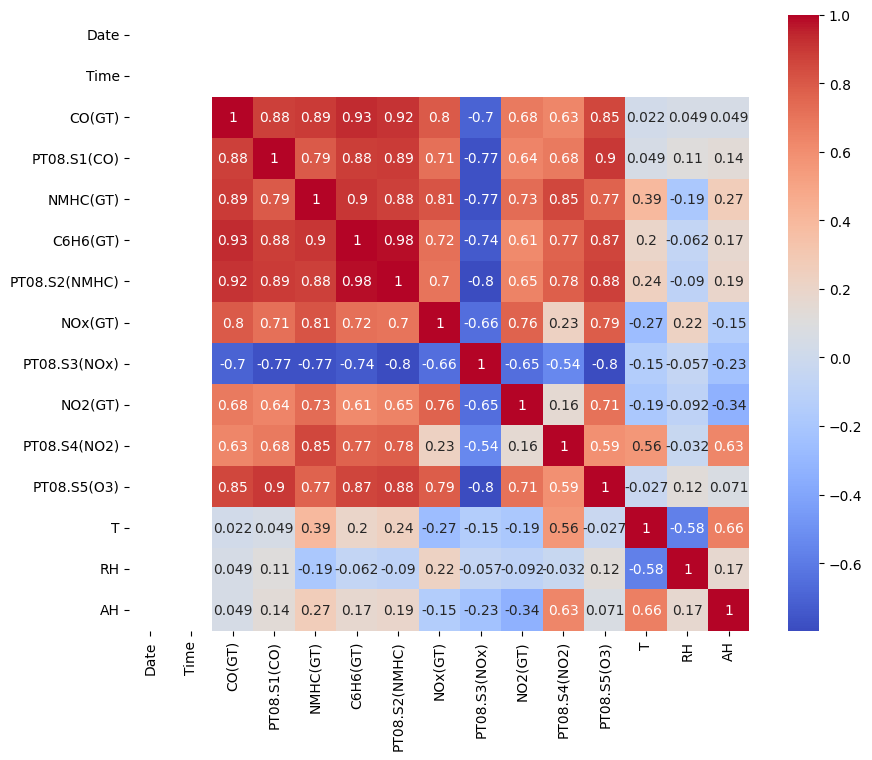

In [87]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

El análisis entre NOx(GT) y PT08.S1(CO) muestra una relación positiva moderada. Esto sugiere que cuando aumenta la concentración de óxidos de nitrógeno, también tienden a incrementarse los niveles de monóxido de carbono. Esta relación es consistente con fuentes comunes de contaminación como el tráfico vehicular.

##6. Identificación de patrones

A partir del análisis exploratorio, se identificaron varios patrones relevantes. En primer lugar, se detectó la presencia de valores atípicos en múltiples variables, principalmente asociados a picos de contaminación. Asimismo, se identificaron valores de -200 que representan datos faltantes, los cuales fueron tratados adecuadamente.

En cuanto a las relaciones entre variables, se observó una correlación positiva entre distintos contaminantes como NOx y CO, lo que sugiere fuentes comunes de emisión. El análisis multivariado confirmó que los sensores presentan alta correlación con las variables que miden, lo cual valida la calidad de los datos.

No se identificaron clusters claramente definidos, pero sí tendencias en la concentración de contaminantes. Finalmente, las variables más relevantes para el análisis son aquellas relacionadas con gases contaminantes y sus sensores asociados.